In [1]:
import pandas as pd #  pandas
import numpy as np # numpy
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint # pprint para visualización metadatos
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import seaborn as sns # seaborn
import statsmodels.api as sm #statsmodels
from sklearn.model_selection import train_test_split # para dividir los datos en train y test
from sklearn.preprocessing import StandardScaler, LabelEncoder # para estandarizar los datos
from sklearn.linear_model import LogisticRegression # RL
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # informes de resultados
from sklearn.model_selection import GridSearchCV # para grid search
from sklearn.tree import DecisionTreeClassifier # DT
from sklearn.ensemble import RandomForestClassifier # RF
from sklearn.neighbors import KNeighborsClassifier #kNN
from sklearn.svm import SVC # SVC
from sklearn.naive_bayes import GaussianNB # GNß
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # LDA
from sklearn.metrics import recall_score # recall
from sklearn.neural_network import MLPClassifier # MLP
import shap # SHAP
import lime # LIME
from lime import lime_tabular # LIME
import xgboost as xgb # xgboost
import os # os

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

In [ ]:
"""
CARGA DE BASE DE DATOS LOCAL 
- Emplear si el servidor UCI Machine Learning Repository se cae

# ruta local
ruta_darwin = os.path.expanduser("/Users/joseromerodegaetano/Desktop/DARWIN/DARWIN.csv") 

try:

    # Se carga el dataset
    df = pd.read_csv(ruta_darwin)

    x = df.drop(columns=['class'])
    y = df['class']

    print('Dataset DARWIN cargado correctamente')

except FileNotFoundError:
    print(f"No se encuentra el archivo .csv DARWIN en {ruta_darwin}")
"""

Columna ID eliminada
Dataset DARWIN cargado correctamente


In [ ]:
def analizar_tarea(df, num_tarea): # función analizar_tarea
    """
    Analiza una tarea específica (1-25)
    """
    suffix = str(num_tarea) # sufijo
    
    # --- FILTRADO ---
    # Se buscan las columnas que terminen en el número de tarea, 
    # Se asegura que el número anterior NO sea otro dígito.
    cols_tarea = [] # lista vacia
    for col in df.columns: # se recorren las columnas
        if col.endswith(suffix): # cuando la col acaba en el sufijo
            # Se verifica el prefijo del número 
            posible_prefijo = col[:-(len(suffix))] # prefijo
            # si el último caracter del prefijo no es un número se añade
            if not posible_prefijo[-1:].isdigit(): 
                cols_tarea.append(col)

    if not cols_tarea: # si no se encuentran columnas con el sufijo dado
        print(f"No se encontraron columnas para la tarea {num_tarea}")
        return None

    print(f"Analizando Tarea {num_tarea} ({len(cols_tarea)} variables)")

    # Se crea un un subset con las variables de la tarea + la clase
    df_tarea = df[cols_tarea + ['class']].copy()

    print(f"Tarea {num_tarea} extraída: {len(cols_tarea)} variables + 'class'.")
    return df_tarea

    # --- EJECUCIÓN ---
df_1 = analizar_tarea(df, 1)
df_2 = analizar_tarea(df, 2)
df_3 = analizar_tarea(df, 3)
df_4 = analizar_tarea(df, 4)
df_5 = analizar_tarea(df, 5)
df_6 = analizar_tarea(df, 6)
df_7 = analizar_tarea(df, 7)
df_8 = analizar_tarea(df, 8)
df_9 = analizar_tarea(df, 9)
df_10 = analizar_tarea(df, 10)
df_11 = analizar_tarea(df, 11)
df_12 = analizar_tarea(df, 12)
df_13 = analizar_tarea(df, 13)
df_14 = analizar_tarea(df, 14)
df_15 = analizar_tarea(df, 15)
df_16 = analizar_tarea(df, 16)
df_17 = analizar_tarea(df, 17)
df_18 = analizar_tarea(df, 18)
df_19 = analizar_tarea(df, 19)
df_20 = analizar_tarea(df, 20)
df_21 = analizar_tarea(df, 21)
df_22 = analizar_tarea(df, 22)
df_23 = analizar_tarea(df, 23)
df_24 = analizar_tarea(df, 24)
df_25 = analizar_tarea(df, 25)

Analizando Tarea 1 (18 variables)
Tarea 1 extraída: 18 variables + 'class'.
Analizando Tarea 2 (18 variables)
Tarea 2 extraída: 18 variables + 'class'.
Analizando Tarea 3 (18 variables)
Tarea 3 extraída: 18 variables + 'class'.
Analizando Tarea 4 (18 variables)
Tarea 4 extraída: 18 variables + 'class'.
Analizando Tarea 5 (18 variables)
Tarea 5 extraída: 18 variables + 'class'.
Analizando Tarea 6 (18 variables)
Tarea 6 extraída: 18 variables + 'class'.
Analizando Tarea 7 (18 variables)
Tarea 7 extraída: 18 variables + 'class'.
Analizando Tarea 8 (18 variables)
Tarea 8 extraída: 18 variables + 'class'.
Analizando Tarea 9 (18 variables)
Tarea 9 extraída: 18 variables + 'class'.
Analizando Tarea 10 (18 variables)
Tarea 10 extraída: 18 variables + 'class'.
Analizando Tarea 11 (18 variables)
Tarea 11 extraída: 18 variables + 'class'.
Analizando Tarea 12 (18 variables)
Tarea 12 extraída: 18 variables + 'class'.
Analizando Tarea 13 (18 variables)
Tarea 13 extraída: 18 variables + 'class'.
Anal

In [13]:
# Se elimina la columna ID
# X = df (sin 'ID' ni 'class'), axis = 1 para cols
X = df_19.drop(['class'], axis = 1)

# Y contiene 'class'
Y = df_19['class']

# Se codficia paciente (P) -> 1 y sano (H) -> 0
le = LabelEncoder()
Y = le.fit_transform(Y)

# Se dividen los datos en 80% para train y 20% para test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Se revisa la correcta división de los datos
print(f"Datos de entrenamiento {len(X_train)}")
print(f"Datos test {len(X_test)}")

Datos de entrenamiento 139
Datos test 35


In [3]:
# Se elimina la columna ID
# X = df (sin 'ID' ni 'class'), axis = 1 para cols
X = df.drop(['class'], axis = 1)

# Y contiene 'class'
Y = df['class']

# Se codficia paciente (P) -> 1 y sano (H) -> 0
le = LabelEncoder()
Y = le.fit_transform(Y)

# Se dividen los datos en 80% para train y 20% para test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Se revisa la correcta división de los datos
print(f"Datos de entrenamiento {len(X_train)}")
print(f"Datos test {len(X_test)}")

Datos de entrenamiento 139
Datos test 35


In [6]:
# StandardScaler()
scaler = StandardScaler()

"""".
Se añaden las primeras 5 variables segun importancia para SHAP y que no disminuyan Acc
- Si disminuyen acc se añaden mas variables revisando que no haya variables que esten muy correlacionadas entre si
"""

# Top vars tarea 3 
top_vars_3XGB = ['total_time3', 'max_x_extension3', 'max_y_extension3', 'mean_jerk_in_air3', 'pressure_var3']
top_vars_3GNB = ['paper_time3', 'total_time3', 'max_y_extension3', 'num_of_pendown3'] #mean_acc_in_air3

# Top vars tarea 5
top_vars_5XGB = ['pressure_mean5', 'mean_jerk_on_paper5', 'max_x_extension5', 'total_time5', 'mean_jerk_in_air5',
                 'pressure_var5', 'mean_speed_in_air5']  # max_y_extension5 air_time5 gmrt_in_air5
top_vars_5GNB = ['disp_index5', 'pressure_var5', 'total_time5', 'air_time5'] # max_x_extension5 

# Top vars tarea 7
top_vars_7XGB = ['mean_gmrt7', 'pressure_mean7', 'air_time7'] # mean_speed_in_air7 total_time7
top_vars_7GNB = ['paper_time7', 'pressure_mean7', 'gmrt_in_air7', 'mean_gmrt7', 'mean_speed_in_air7'] 

# Top vars tarea 19
top_vars_19XGB = ['num_of_pendown19', 'pressure_var19', 'air_time19', 'pressure_mean19', 'max_y_extension19',
                   'mean_gmrt19', 'mean_speed_on_paper19'] 
top_vars_19GNB = ['air_time19', 'max_y_extension19', 'mean_acc_in_air19', 'mean_jerk_in_air19',
                  'gmrt_in_air19', 'mean_jerk_on_paper19', 'pressure_mean19'] #total_time19

# Top vars totales (22 para XGB y 20 para GNB)
top_vars_XGB = ['total_time3', 'max_x_extension3', 'max_y_extension3', 'mean_jerk_in_air3', 'pressure_var3',
                'pressure_mean5', 'mean_jerk_on_paper5', 'max_x_extension5', 'total_time5', 'mean_jerk_in_air5',
                'pressure_var5', 'mean_speed_in_air5', 'mean_gmrt7', 'pressure_mean7', 'air_time7', 'num_of_pendown19', 
                'pressure_var19', 'air_time19', 'pressure_mean19', 'max_y_extension19','mean_gmrt19', 'mean_speed_on_paper19']

top_vars_GNB = ['paper_time3', 'total_time3', 'max_y_extension3', 'num_of_pendown3','disp_index5', 
                'pressure_var5', 'total_time5', 'air_time5', 'paper_time7', 'pressure_mean7', 'gmrt_in_air7', 
                'mean_gmrt7', 'mean_speed_in_air7', 'air_time19', 'max_y_extension19', 'mean_acc_in_air19', 
                'mean_jerk_in_air19', 'gmrt_in_air19', 'mean_jerk_on_paper19', 'pressure_mean19']

# Se ajusta la estandarización con X_train con las variables seleccionadas
X_train_scaled = scaler.fit_transform(X_train[top_vars_XGB])

# Se aplica la transformación al test con las variables seleccionadas
X_test_scaled = scaler.transform(X_test[top_vars_XGB])

# ANÁLISIS DE ML 5

## XGBOOST

In [7]:
# Modelo
modelo_xgb = xgb.XGBClassifier(
    n_estimators = 100, # nº árboles
    learning_rate = 0.1, # paso de aprendizaje
    max_depth = 3, # profundidad árboles
    use_label_encoder = False,
    eval_metrics = 'logloss',
    base_score=0.5
)

# Se entrena
modelo_xgb.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_xgb = modelo_xgb.predict(X_test_scaled)

# Informe de clasificación
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_xgb))

# Matriz de confusión
print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_xgb))

# TP; TN; FP; FN
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(Y_test, Y_pred_xgb).ravel()

print(f"Sensibilidad: {tp_xgb / (tp_xgb + fn_xgb):.2f}") # sensibilidad
print(f"Especificidad: {tn_xgb / (tn_xgb + fp_xgb):.2f}") # especificidad

 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        17
           1       0.89      0.89      0.89        18

    accuracy                           0.89        35
   macro avg       0.89      0.89      0.89        35
weighted avg       0.89      0.89      0.89        35

--- MATRIZ DE CONFUSIÓN ---
[[15  2]
 [ 2 16]]
Sensibilidad: 0.89
Especificidad: 0.88


/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [10:37:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


**SHAP**

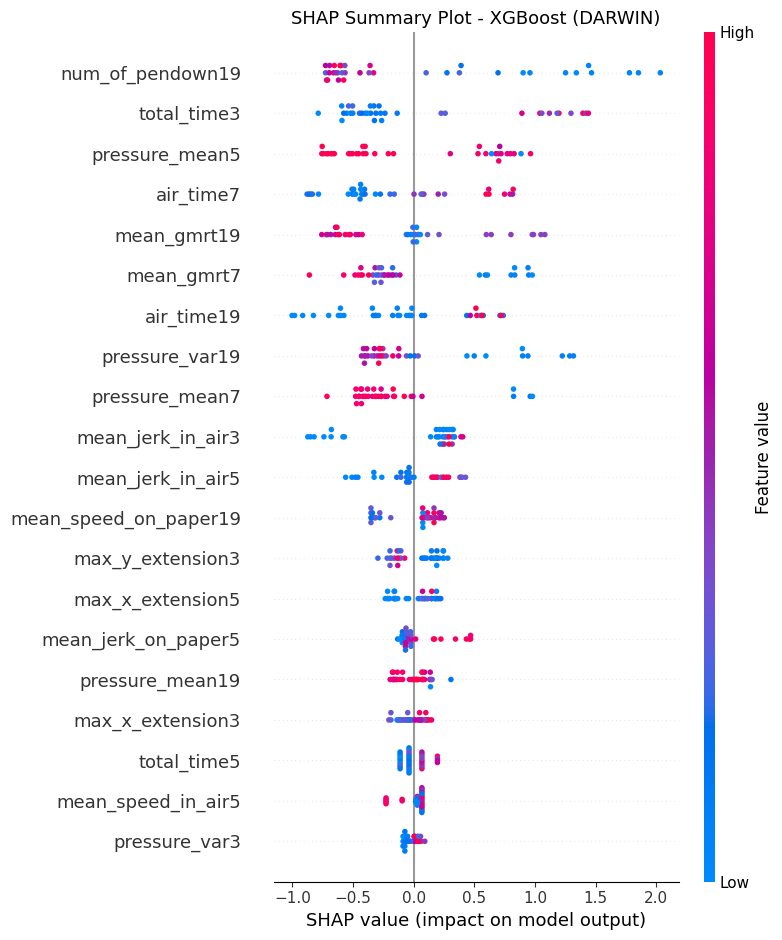

Summary plot guardado.


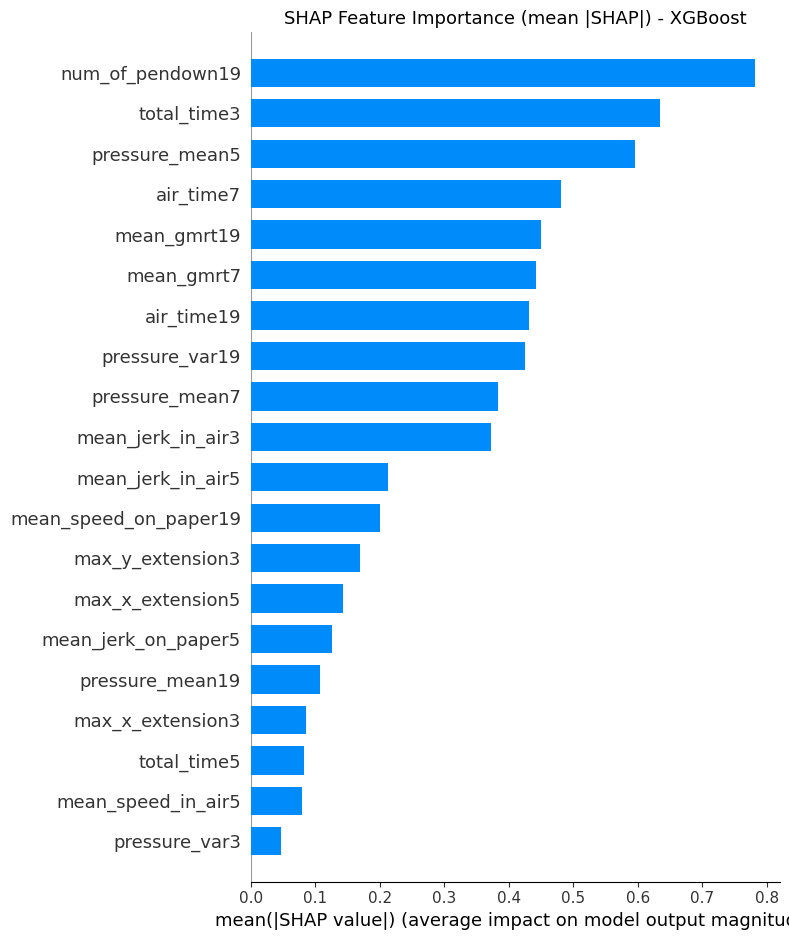

Bar plot guardado.


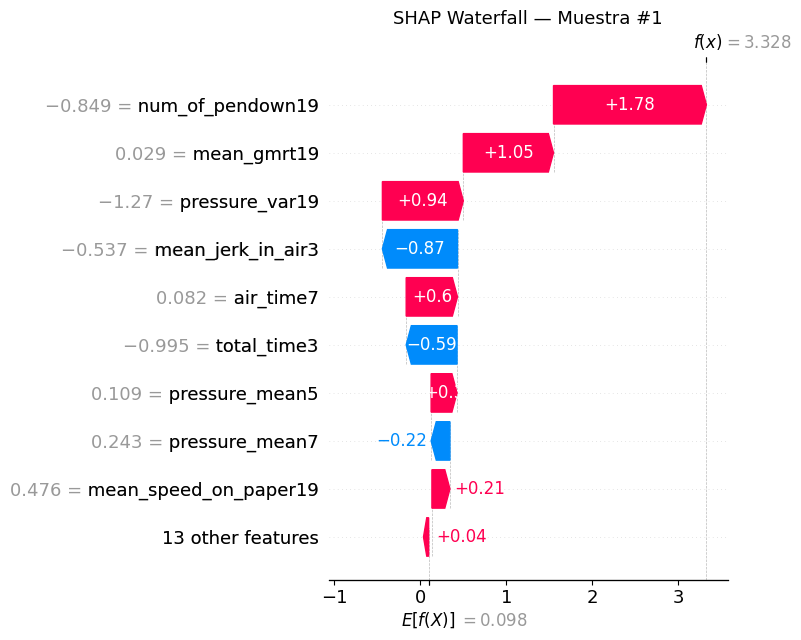

Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

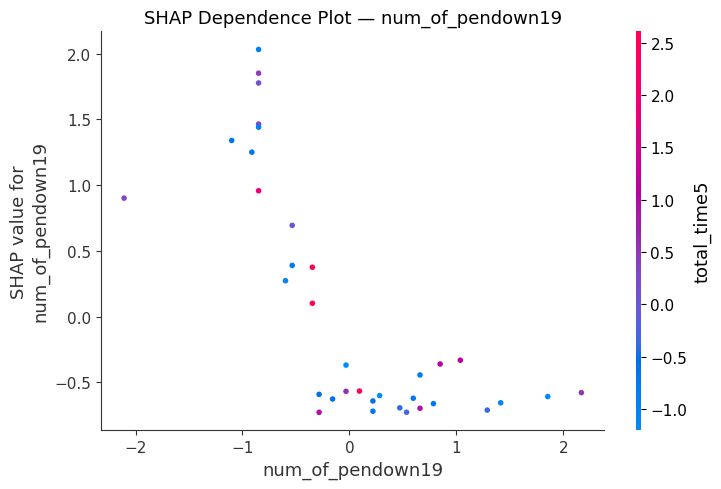

Dependence plot guardado para: num_of_pendown19

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP) ===
          Feature  Mean |SHAP|
 num_of_pendown19     0.781235
      total_time3     0.634651
   pressure_mean5     0.595877
        air_time7     0.480954
      mean_gmrt19     0.450159
       mean_gmrt7     0.442222
       air_time19     0.430982
   pressure_var19     0.425644
   pressure_mean7     0.383269
mean_jerk_in_air3     0.372826


In [ ]:
# ============================================================
# ANÁLISIS SHAP PARA XGBOOST
# ============================================================

# Explainer SHAP (TreeExplainer es el óptimo para XGBoost)
explainer = shap.TreeExplainer(modelo_xgb) # 2

# Calcular los SHAP values sobre el test set
shap_values = explainer.shap_values(X_test_scaled)

# ============================================================
# Summary Plot (Beeswarm)
# ============================================================
plt.figure() # figura
shap.summary_plot(
    shap_values, # shap values
    X_test_scaled, # vars
    feature_names=top_vars_XGB, # nombres
    show=False
)
plt.title("SHAP Summary Plot - XGBoost (DARWIN)", fontsize=13) # título
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches='tight') # guardado
plt.show() # se muestra
print("Summary plot guardado.")

# ============================================================
# Bar Plot 
# ============================================================
plt.figure() # figura
shap.summary_plot(
    shap_values, # shap values
    X_test_scaled, # vars
    feature_names=top_vars_XGB, # nombres
    plot_type="bar", # barplot
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - XGBoost", fontsize=13) # título
plt.tight_layout()
plt.savefig("shap_bar_importance.png", dpi=150, bbox_inches='tight') # guardado
plt.show() # se muestra
print("Bar plot guardado.")

# ============================================================
# Waterfall Plot
# ============================================================
sample_idx = 1 # índice de fila

explanation = shap.Explanation(
    values=shap_values[sample_idx], # valores específicos a la fila
    base_values=explainer.expected_value, # predicción promedio
    data=X_test_scaled[sample_idx] if hasattr(X_test_scaled, '__array__') else X_test_scaled.iloc[sample_idx].values,
    feature_names=top_vars_XGB # nombres
)

plt.figure() # figura
shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx}", fontsize=13) # título
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight') # guardado
plt.show() # se muestra
print("Waterfall plot guardado.")

# ============================================================
# Dependence Plot 
# ============================================================
# Se identifica la feature con mayor impacto medio
mean_abs_shap = np.abs(shap_values).mean(axis=0) # importancia global
top_feature_idx = np.argmax(mean_abs_shap) # idc promedio mas alto
top_feature_name = top_vars_XGB[top_feature_idx]  # idc a nombre

plt.figure() # figura
shap.dependence_plot(
    top_feature_idx,
    shap_values, # shap values
    X_test_scaled, # vars
    feature_names=top_vars_XGB, # nombres
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name}", fontsize=13) # título
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches='tight') # guardado
plt.show() # se muestra
print(f"Dependence plot guardado para: {top_feature_name}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features por |SHAP| medio
# ============================================================
feature_importance_df = pd.DataFrame({ # df
    'Feature': top_vars_XGB, # variables
    'Mean |SHAP|': mean_abs_shap # variables mas influyentes
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP) ===")
print(feature_importance_df.head(10).to_string(index=False)) # variables mas importantes

**LIME**


--- LIME XGBoost: instancia 1 ---
Clase real     : 1
Clase predicha : 1
Probabilidades : H=0.035 | P=0.965

Top features (peso LIME):
  num_of_pendown19 <= -0.85                      +0.2477
  air_time7 > -0.09                              +0.1770
  mean_jerk_in_air3 <= -0.51                     -0.1674
  total_time3 <= -0.71                           -0.1557
  pressure_var19 <= -0.80                        +0.1399
  pressure_mean5 <= 0.14                         +0.1210
  -0.67 < mean_gmrt19 <= 0.03                    +0.0673
  -0.36 < pressure_mean7 <= 0.40                 -0.0619
  mean_jerk_in_air5 > -0.06                      +0.0566
  0.10 < mean_speed_on_paper19 <= 0.48           +0.0337
  mean_speed_in_air5 > 0.30                      -0.0332
  max_x_extension5 > -0.08                       +0.0321
  -0.84 < mean_gmrt7 <= 0.01                     -0.0228
  -0.65 < max_y_extension3 <= -0.25              +0.0209
  -0.26 < air_time19 <= -0.25                    -0.0104


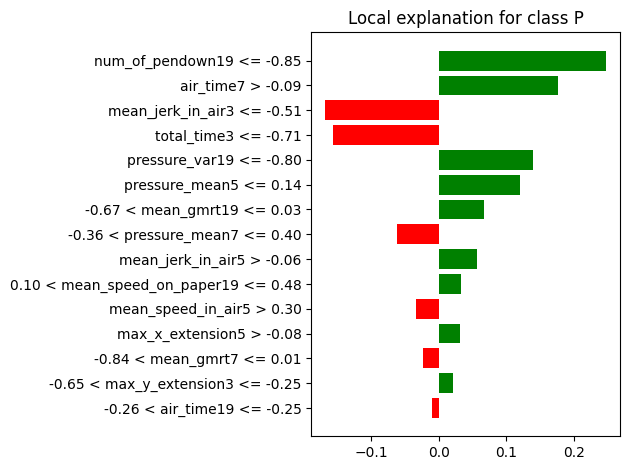


Calculando importancia global LIME (XGBoost)...

Top-20 features por importancia global LIME (XGBoost):
   1. num_of_pendown19                          0.13819
   2. pressure_mean5                            0.11724
   3. total_time3                               0.11670
   4. air_time7                                 0.09662
   5. air_time19                                0.08321
   6. mean_jerk_in_air3                         0.08229
   7. mean_gmrt7                                0.08213
   8. pressure_mean7                            0.08085
   9. pressure_var19                            0.07849
  10. mean_gmrt19                               0.06666
  11. mean_jerk_in_air5                         0.04936
  12. mean_jerk_on_paper5                       0.03359
  13. max_x_extension5                          0.03075
  14. max_y_extension3                          0.02539
  15. mean_speed_on_paper19                     0.02461
  16. total_time5                               0.02393

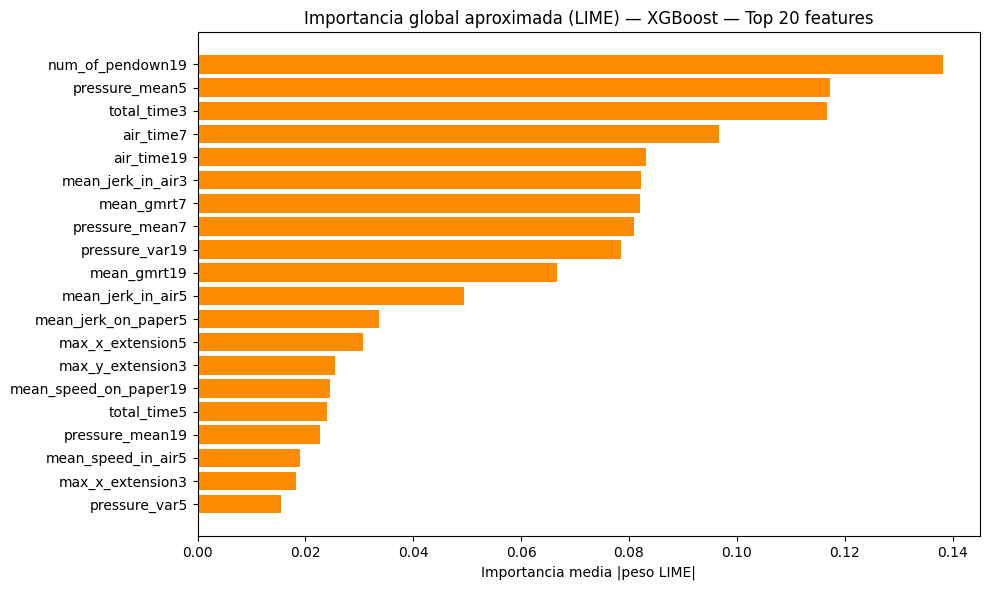

In [11]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO XGBoost
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled, # training
    feature_names = top_vars_XGB, # nombres
    class_names   = ["H", "P"], # clases
    mode          = "classification", # clasificación
    random_state  = 42 # semilla
)

# ── Explicación individual ──
INSTANCE_IDX = 1 # instancia 1 (2º fila)
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = modelo_xgb.predict_proba, # función
    num_features = 15, # variables
    num_samples  = 5000  # muestras
)

print(f"\n--- LIME XGBoost: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}") # real
print(f"Clase predicha : {Y_pred_xgb[INSTANCE_IDX]}") # predicción
print(f"Probabilidades : H={modelo_xgb.predict_proba([instance])[0][0]:.3f} | " 
      f"P={modelo_xgb.predict_proba([instance])[0][1]:.3f}") 
print("\nTop features (peso LIME):")
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME (XGBoost)...")

all_weights = {feat: [] for feat in X.columns} # diccionario

for i in range(len(X_test_scaled)): # bucle para importancia
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = modelo_xgb.predict_proba, 
        num_features = len(top_vars_XGB),
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list(): # peso con las variables
        for col in top_vars_XGB:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = { # importancia global
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20] # varibles de mayor a menor imp

print("\nTop-20 features por importancia global LIME (XGBoost):") # ranking global
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

# Visualización del ranking global
feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="darkorange")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — XGBoost — Top 20 features")
plt.tight_layout()
plt.show()

## Gaussian Naive Bayes

In [9]:
# Modelo
gnb = GaussianNB()

# Se entrena el modelo
gnb.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_gnb = gnb.predict(X_test_scaled)

# Informe de clasificación
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_gnb))

# Matriz de confusión
print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_gnb))

# TP; TN; FP; FN
tn_gnb, fp_gnb, fn_gnb, tp_gnb = confusion_matrix(Y_test, Y_pred_gnb).ravel()

print(f"Sensibilidad: {tp_gnb / (tp_gnb + fn_gnb):.2f}") # sensibilidad
print(f"Especificidad: {tn_gnb / (tn_gnb + fp_gnb):.2f}") # especificidad

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        17
           1       0.83      0.83      0.83        18

    accuracy                           0.83        35
   macro avg       0.83      0.83      0.83        35
weighted avg       0.83      0.83      0.83        35

 --- MATRIZ DE CONFUSIÓN ---
[[14  3]
 [ 3 15]]
Sensibilidad: 0.83
Especificidad: 0.82


**SHAP**

100%|██████████| 35/35 [00:11<00:00,  3.05it/s]


Shape shap_values_gnb: (35, 20, 2)
Shape sv_gnb: (35, 20)
expected_value shape: (2,)
expected_value: [0.50950105 0.49049895]
base_val usado: 0.4904989519304764


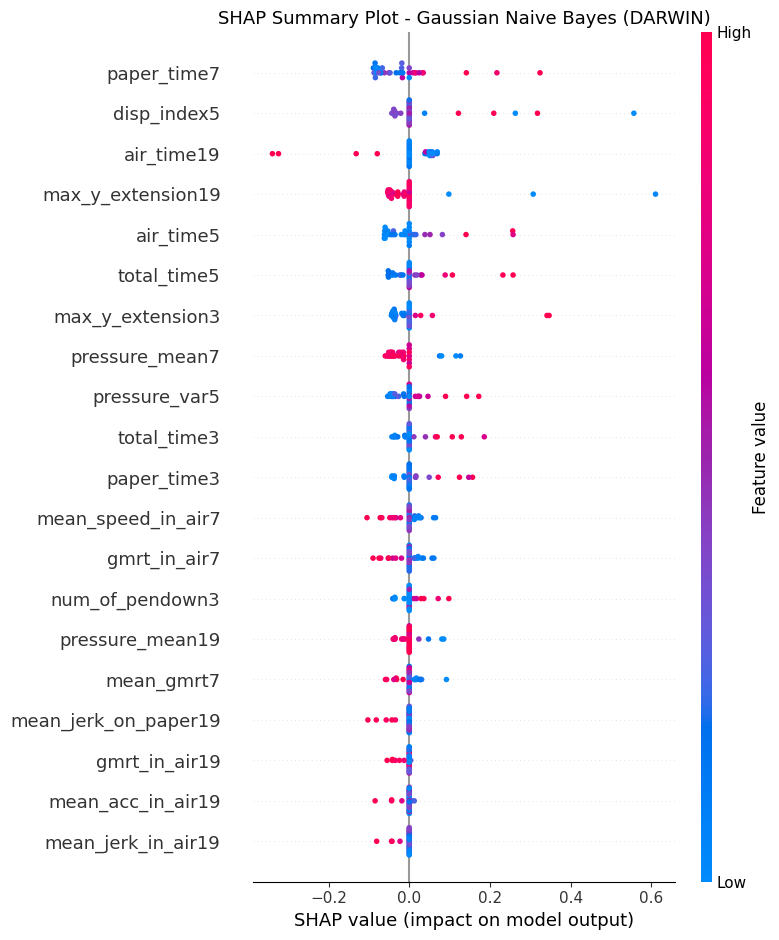

Summary plot guardado.


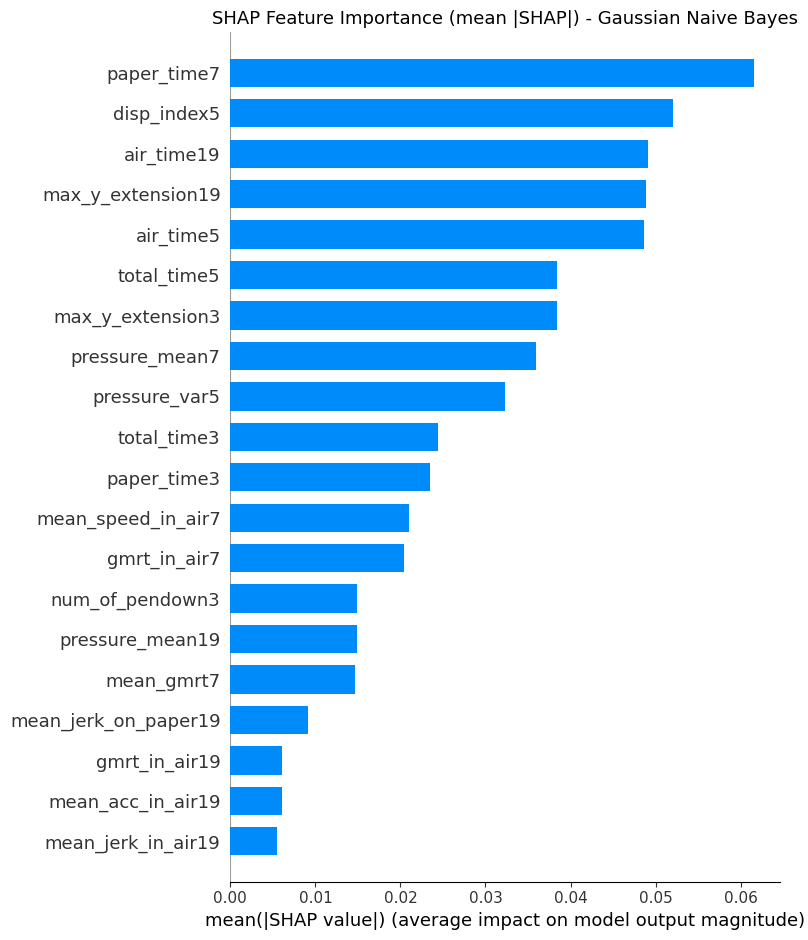

Bar plot guardado.


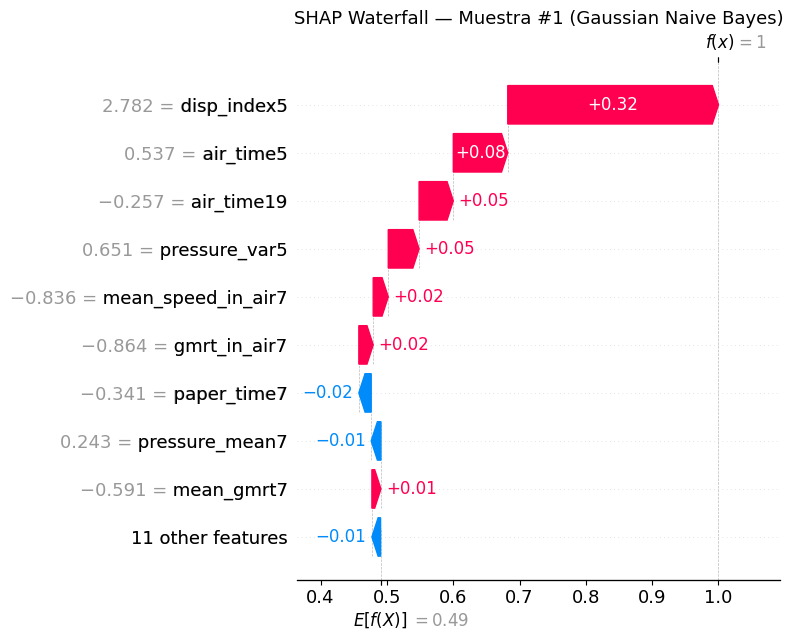

Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

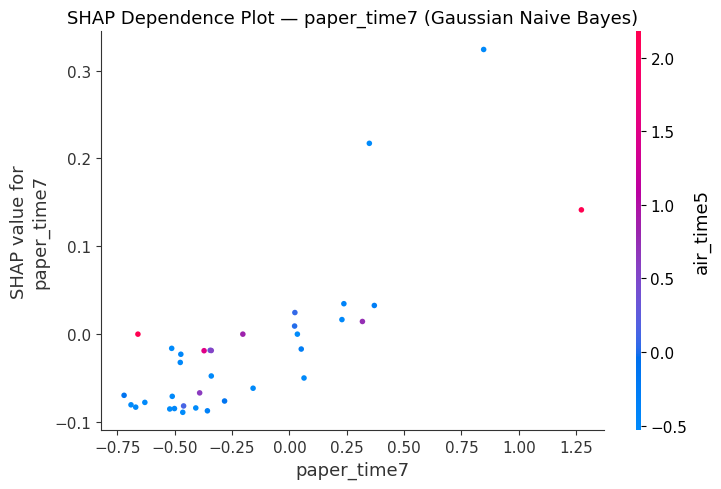

Dependence plot guardado para: paper_time7

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Gaussian Naive Bayes) ===
          Feature  Mean |SHAP|
      paper_time7     0.061555
      disp_index5     0.052001
       air_time19     0.049154
max_y_extension19     0.048855
        air_time5     0.048689
      total_time5     0.038463
 max_y_extension3     0.038438
   pressure_mean7     0.035919
    pressure_var5     0.032274
      total_time3     0.024386


In [10]:
# ============================================================
# ANÁLISIS SHAP PARA GAUSSIAN NAIVE BAYES
# ============================================================

background = shap.sample(X_train_scaled, 100)  # 100 muestras como background

# Explainer 
explainer_gnb = shap.KernelExplainer(gnb.predict_proba, background)

# SHAP values
shap_values_gnb = explainer_gnb.shap_values(X_test_scaled, nsamples="auto")

# Se verifica la estructura
print("Shape shap_values_gnb:", np.array(shap_values_gnb).shape)


# Se extrae la clase positiva (P = 1)
sv_gnb = shap_values_gnb[:, :, 1]  # shape (35, 450)
print("Shape sv_gnb:", sv_gnb.shape)

# Se convierte X_test_scaled a DataFrame para que los plots usen nombres de features
X_test_df = pd.DataFrame(X_test_scaled, columns=top_vars_GNB)

# expected_value para clase positiva
ev = np.array(explainer_gnb.expected_value)
print("expected_value shape:", ev.shape)
print("expected_value:", ev)

# Si ev tiene shape (n_muestras, 2) se usa la media; si es (2,) usamos índice 1
if ev.ndim == 2:
    base_val = ev[:, 1].mean()
elif ev.ndim == 1:
    base_val = ev[1]
else:
    base_val = float(ev)

print("base_val usado:", base_val)

# ============================================================
# Summary Plot (Beeswarm)
# ============================================================
plt.figure() # figura
shap.summary_plot(
    sv_gnb, # shap values
    X_test_df, # df
    show=False
)
plt.title("SHAP Summary Plot - Gaussian Naive Bayes (DARWIN)", fontsize=13) # título
plt.tight_layout()
plt.savefig("shap_gnb_summary_beeswarm.png", dpi=150, bbox_inches='tight') # guardado
plt.show() # se muestra
print("Summary plot guardado.")

# ============================================================
# Bar Plot — Importancia media global
# ============================================================
plt.figure() # figura
shap.summary_plot(
    sv_gnb, # shap values
    X_test_df, # df
    plot_type="bar", # bar plot
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Gaussian Naive Bayes", fontsize=13) # título
plt.tight_layout()
plt.savefig("shap_gnb_bar_importance.png", dpi=150, bbox_inches='tight') # guardado
plt.show() # se muestra
print("Bar plot guardado.")

# ============================================================
# Waterfall Plot — Explicación individual
# ============================================================
sample_idx = 1 # índice de fila

explanation_gnb = shap.Explanation(
    values=sv_gnb[sample_idx], # valores específicos a la fila
    base_values=base_val, # predicción promedio
    data=X_test_df.iloc[sample_idx],
    feature_names=top_vars_GNB # nombres
)
plt.figure() # figura
shap.plots.waterfall(explanation_gnb, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Gaussian Naive Bayes)", fontsize=13) # título
plt.tight_layout()
plt.savefig("shap_gnb_waterfall.png", dpi=150, bbox_inches='tight') # guardado
plt.show() # se muestra
print("Waterfall plot guardado.")

# ============================================================
# Dependence Plot — Feature más importante
# ============================================================
# Se identifica la feature con mayor impacto medio
mean_abs_shap_gnb = np.abs(sv_gnb).mean(axis=0) # importancia global
top_feature_idx_gnb = np.argmax(mean_abs_shap_gnb) # idc promedio mas alto
top_feature_name_gnb = top_vars_GNB[top_feature_idx_gnb] # idc a nombre

plt.figure() # figura
shap.dependence_plot(
    top_feature_idx_gnb,
    sv_gnb, # shap values
    X_test_df, # df
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_gnb} (Gaussian Naive Bayes)", fontsize=13) # título
plt.tight_layout()
plt.savefig("shap_gnb_dependence.png", dpi=150, bbox_inches='tight') # guardado
plt.show() # se muestra
print(f"Dependence plot guardado para: {top_feature_name_gnb}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
feature_importance_gnb_df = pd.DataFrame({ # df
    'Feature': top_vars_GNB, # variables
    'Mean |SHAP|': mean_abs_shap_gnb # variables mas influyentes
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Gaussian Naive Bayes) ===")
print(feature_importance_gnb_df.head(10).to_string(index=False)) # variables mas importantes

**LIME**


--- LIME: instancia 1 (Gaussian Naive Bayes) ---
Clase real     : 1
Clase predicha : 1
Probabilidades : H=0.000 | P=1.000

Top features (peso LIME):
  -0.26 < air_time19 <= -0.25                    +0.2643
  air_time5 > 0.05                               +0.1352
  pressure_var5 > 0.41                           +0.1209
  disp_index5 > 0.08                             +0.0764
  mean_speed_in_air7 <= -0.80                    +0.0498
  0.29 < max_y_extension19 <= 0.41               -0.0360
  -0.36 < pressure_mean7 <= 0.40                 -0.0326
  total_time3 <= -0.71                           -0.0273
  pressure_mean19 > 0.75                         -0.0272
  num_of_pendown3 <= -0.72                       -0.0241
  -0.34 < paper_time7 <= 0.03                    -0.0207
  gmrt_in_air7 <= -0.81                          +0.0189
  -0.66 < gmrt_in_air19 <= -0.35                 +0.0186
  -0.77 < mean_jerk_in_air19 <= -0.07            +0.0148
  -0.32 < total_time5 <= 0.29                    -0.

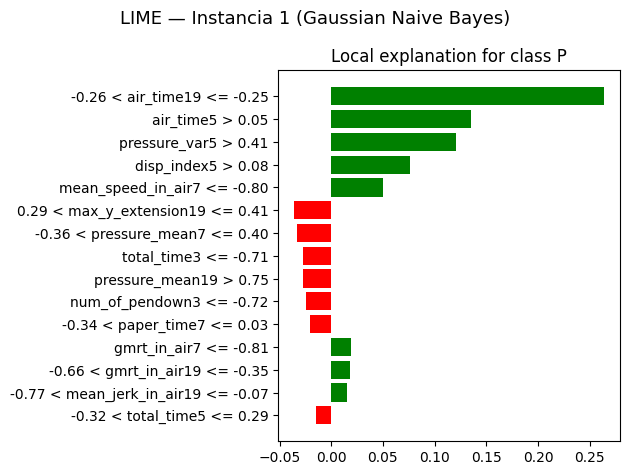


Calculando importancia global LIME (GNB)...

Top-20 features por importancia global LIME (Gaussian Naive Bayes):
   1. air_time19                                0.38538
   2. paper_time7                               0.09001
   3. air_time5                                 0.07755
   4. disp_index5                               0.06490
   5. pressure_var5                             0.05693
   6. total_time5                               0.05432
   7. max_y_extension19                         0.05202
   8. gmrt_in_air7                              0.04342
   9. total_time3                               0.04234
  10. pressure_mean19                           0.03861
  11. mean_speed_in_air7                        0.03834
  12. pressure_mean7                            0.03755
  13. paper_time3                               0.03712
  14. num_of_pendown3                           0.03660
  15. mean_gmrt7                                0.03605
  16. max_y_extension3                        

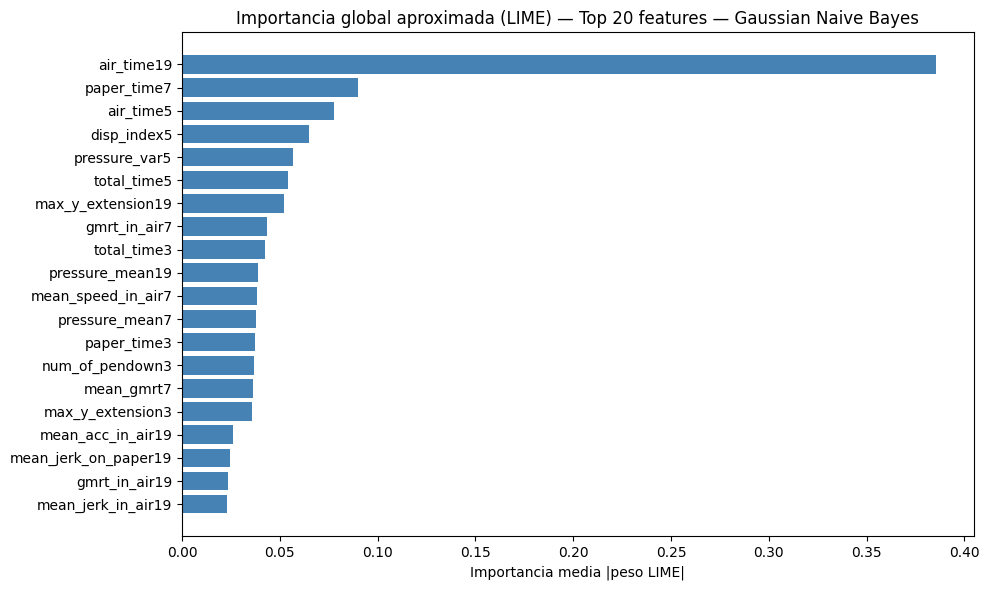

In [11]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO GNB
# ─────────────────────────────────────────

# Explainer
explainer_lime_gnb = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled, # training
    feature_names = top_vars_GNB, # nombres 
    class_names   = ["H", "P"], # clases
    mode          = "classification", # clasificación
    random_state  = 42 # semilla
)

# ── Explicación individual ──
INSTANCE_IDX = 1 # instancia 1 (2º fila)
instance = X_test_scaled[INSTANCE_IDX]

exp_gnb = explainer_lime_gnb.explain_instance(
    data_row     = instance,
    predict_fn   = gnb.predict_proba, # función
    num_features = 15, # variable
    num_samples  = 5000 # muestras
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} (Gaussian Naive Bayes) ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}") # real
print(f"Clase predicha : {gnb.predict([instance])[0]}") # predicción
print(f"Probabilidades : H={gnb.predict_proba([instance])[0][0]:.3f} | "
      f"P={gnb.predict_proba([instance])[0][1]:.3f}")

print("\nTop features (peso LIME):")
for feat, weight in exp_gnb.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp_gnb.as_pyplot_figure()
fig.suptitle(f"LIME — Instancia {INSTANCE_IDX} (Gaussian Naive Bayes)", fontsize=13)
fig.tight_layout()
plt.savefig("lime_gnb_instance.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME (GNB)...")

all_weights_gnb = {feat: [] for feat in top_vars_GNB} # diccionario

for i in range(len(X_test_scaled)): # bucle para importancia
    exp_i = explainer_lime_gnb.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = gnb.predict_proba,
        num_features = len(top_vars_GNB),
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list(): # peso con las variables
        for col in top_vars_GNB:
            if col in feat:
                all_weights_gnb[col].append(abs(weight))
                break

global_importance_gnb = { # promedio global
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights_gnb.items()
}

top_global_gnb = sorted(global_importance_gnb.items(), key=lambda x: x[1], reverse=True)[:20] # variables de mayor a menor imp

print("\nTop-20 features por importancia global LIME (Gaussian Naive Bayes):") # ranking global
for rank, (feat, score) in enumerate(top_global_gnb, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats_gnb, scores_gnb = zip(*top_global_gnb)

# Visualización del ranking global
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats_gnb[::-1], scores_gnb[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features — Gaussian Naive Bayes")
plt.tight_layout()
plt.savefig("lime_gnb_global_importance.png", dpi=150, bbox_inches='tight')
plt.show()